In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../utaut2_dataset/new_result.xlsx')

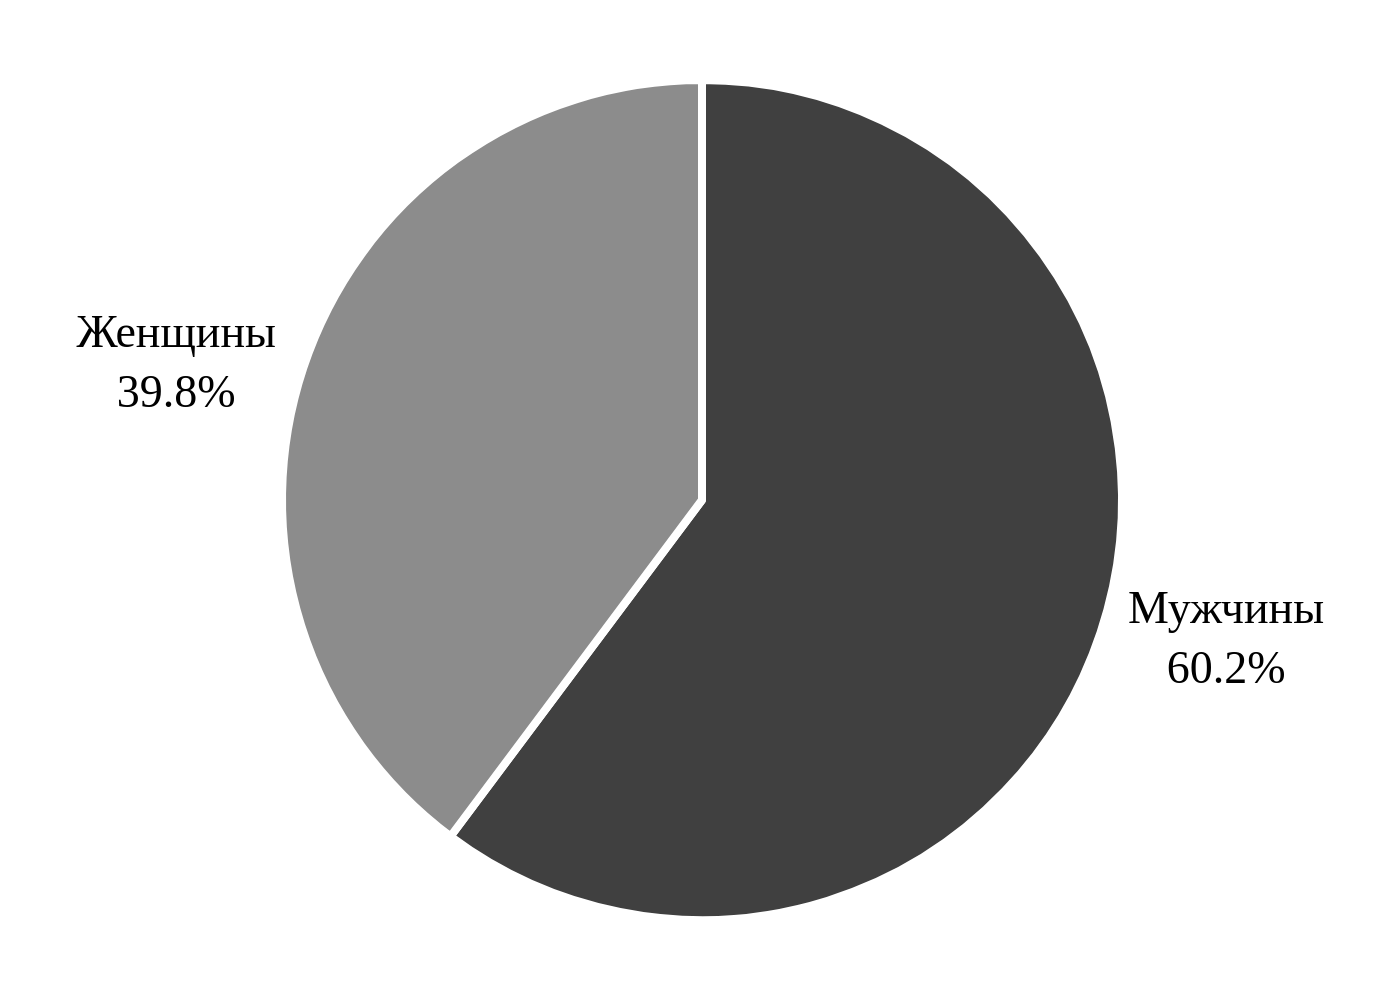

In [2]:
gender_counts = df['What is your gender?'].value_counts()
labels = [{'Male': 'Мужчины', 'Female': 'Женщины'}.get(x, x) for x in gender_counts.index]

fig = go.Figure(data=[go.Pie(
    labels=labels, values=gender_counts.values,
    marker=dict(colors=[PRIMARY, ACCENT], line=dict(color='white', width=4)),
    textposition='outside', textinfo='label+percent',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    hovertemplate='<b>%{label}</b><br>Количество: %{value} чел.<br>Доля: %{percent}<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    margin=dict(l=40, r=40, t=40, b=40))
fig.show()

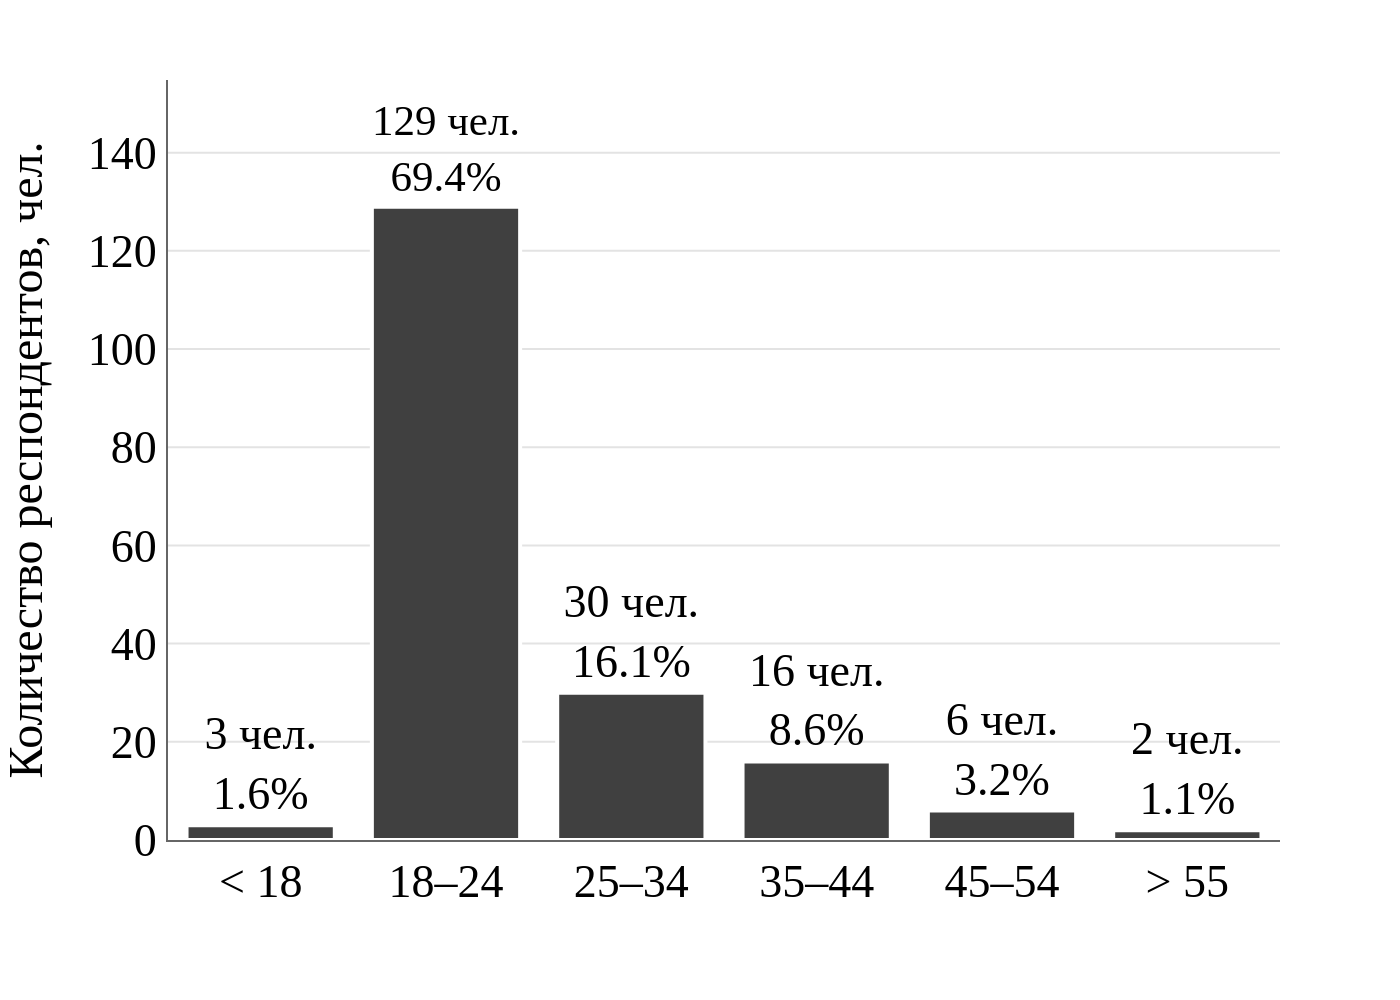

In [3]:
age_order = ['Under 18', '18–24', '25–34', '35–44', '45–54', '55 and older']
age_counts = df['What is your age?'].value_counts().reindex(age_order).fillna(0).astype(int)
age_pct = (age_counts / age_counts.sum() * 100).round(1)
age_ru = {'Under 18': '< 18', '18–24': '18–24', '25–34': '25–34',
          '35–44': '35–44', '45–54': '45–54', '55 and older': '> 55'}

fig = go.Figure(data=[go.Bar(
    x=[age_ru[a] for a in age_counts.index], y=age_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(age_counts.values, age_pct.values)],
    textposition='outside', textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(title='', showgrid=False, tickfont=dict(size=23), linecolor=AXIS_COLOR, linewidth=1),
    yaxis=dict(title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23), showgrid=True, gridcolor=GRID_COLOR,
        zeroline=False, linecolor=AXIS_COLOR, linewidth=1, range=[0, age_counts.max()*1.2]),
    margin=dict(l=60, r=60, t=40, b=60))
fig.show()

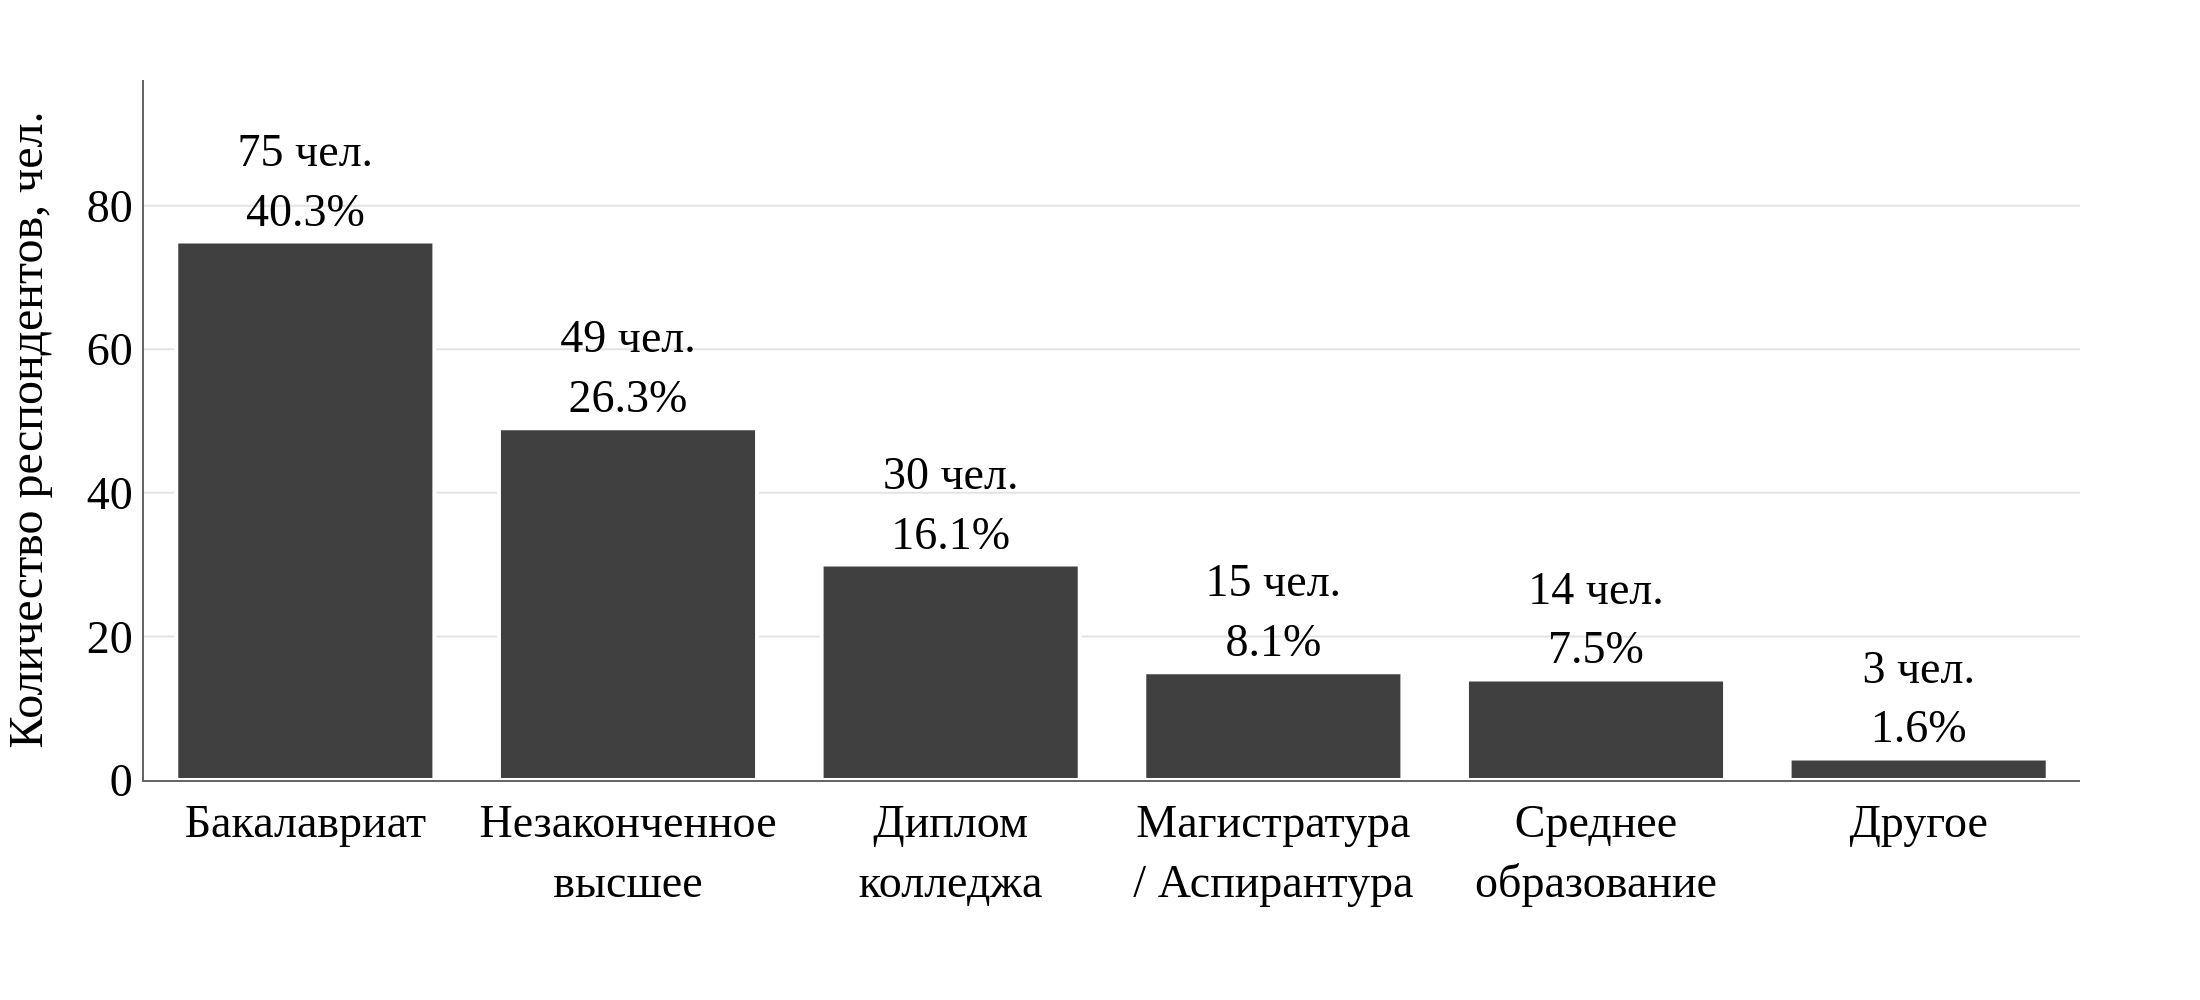

In [4]:
edu_col = 'What is the highest level of education you have completed?'
edu_counts = df[edu_col].value_counts()
edu_pct = (edu_counts / edu_counts.sum() * 100).round(1)
edu_ru = {"Bachelor's degree": "Бакалавриат",
    "Incomplete higher education (Bachelor's)": "Незаконченное<br>высшее",
    "College diploma / Certificate": "Диплом<br>колледжа",
    "Master's degree / Postgraduate": "Магистратура<br>/ Аспирантура",
    "Secondary / High school": "Среднее<br>образование", "Other": "Другое"}

fig = go.Figure(data=[go.Bar(
    x=[edu_ru.get(x, x) for x in edu_counts.index], y=edu_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(edu_counts.values, edu_pct.values)],
    textposition='outside', textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(title='', showgrid=False, tickfont=dict(size=23),
        linecolor=AXIS_COLOR, linewidth=1, tickangle=0),
    yaxis=dict(title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23), showgrid=True, gridcolor=GRID_COLOR,
        zeroline=False, linecolor=AXIS_COLOR, linewidth=1, range=[0, edu_counts.max()*1.3]),
    margin=dict(l=60, r=60, t=40, b=110), width=1100)
fig.show()

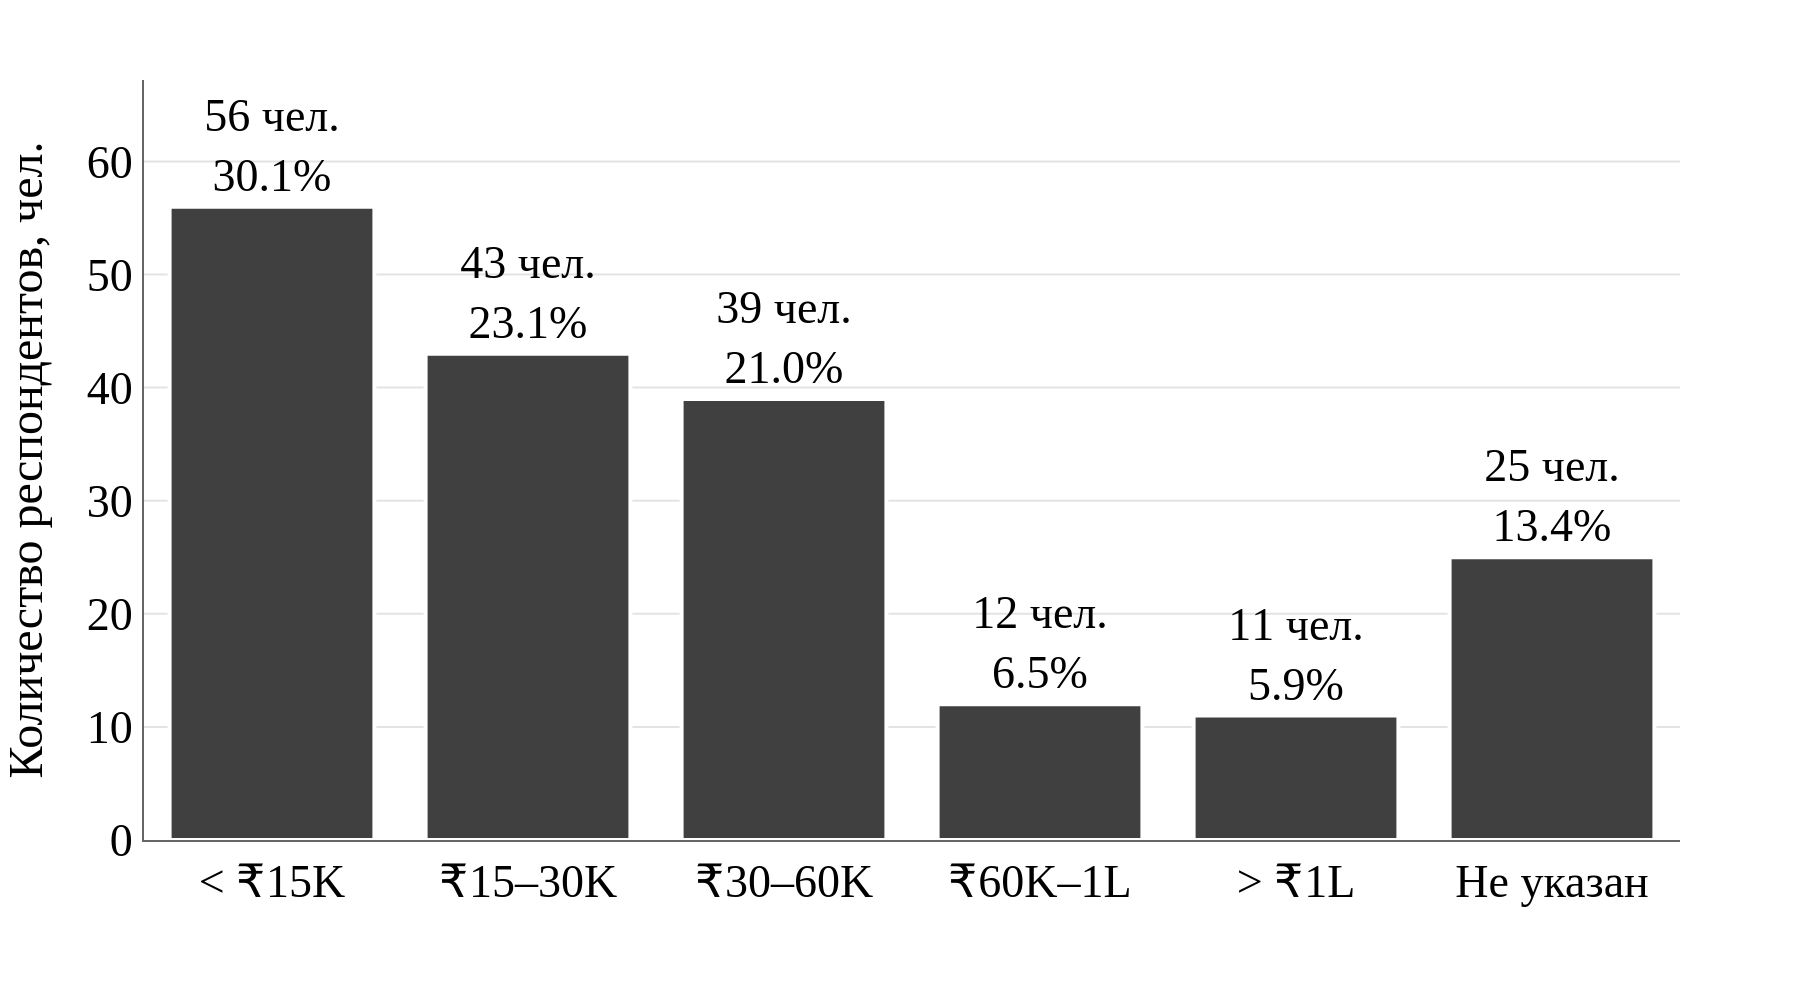

In [5]:
inc_col = 'What is your approximate monthly income?'
inc_order = ['Less than ₹15,000', '₹15,000 – ₹30,000', '₹30,001 – ₹60,000',
             '₹60,001 – ₹1,00,000', 'More than ₹1,00,000', 'Prefer not to say']
inc_counts = df[inc_col].value_counts().reindex(inc_order).fillna(0).astype(int)
inc_pct = (inc_counts / inc_counts.sum() * 100).round(1)
inc_ru = {'Less than ₹15,000': '< ₹15K', '₹15,000 – ₹30,000': '₹15–30K',
           '₹30,001 – ₹60,000': '₹30–60K', '₹60,001 – ₹1,00,000': '₹60K–1L',
           'More than ₹1,00,000': '> ₹1L', 'Prefer not to say': 'Не указан'}

fig = go.Figure(data=[go.Bar(
    x=[inc_ru[x] for x in inc_counts.index], y=inc_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(inc_counts.values, inc_pct.values)],
    textposition='outside', textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(title='', showgrid=False, tickfont=dict(size=23), linecolor=AXIS_COLOR, linewidth=1),
    yaxis=dict(title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23), showgrid=True, gridcolor=GRID_COLOR,
        zeroline=False, linecolor=AXIS_COLOR, linewidth=1, range=[0, inc_counts.max()*1.2]),
    margin=dict(l=60, r=60, t=40, b=60), width=900)
fig.show()

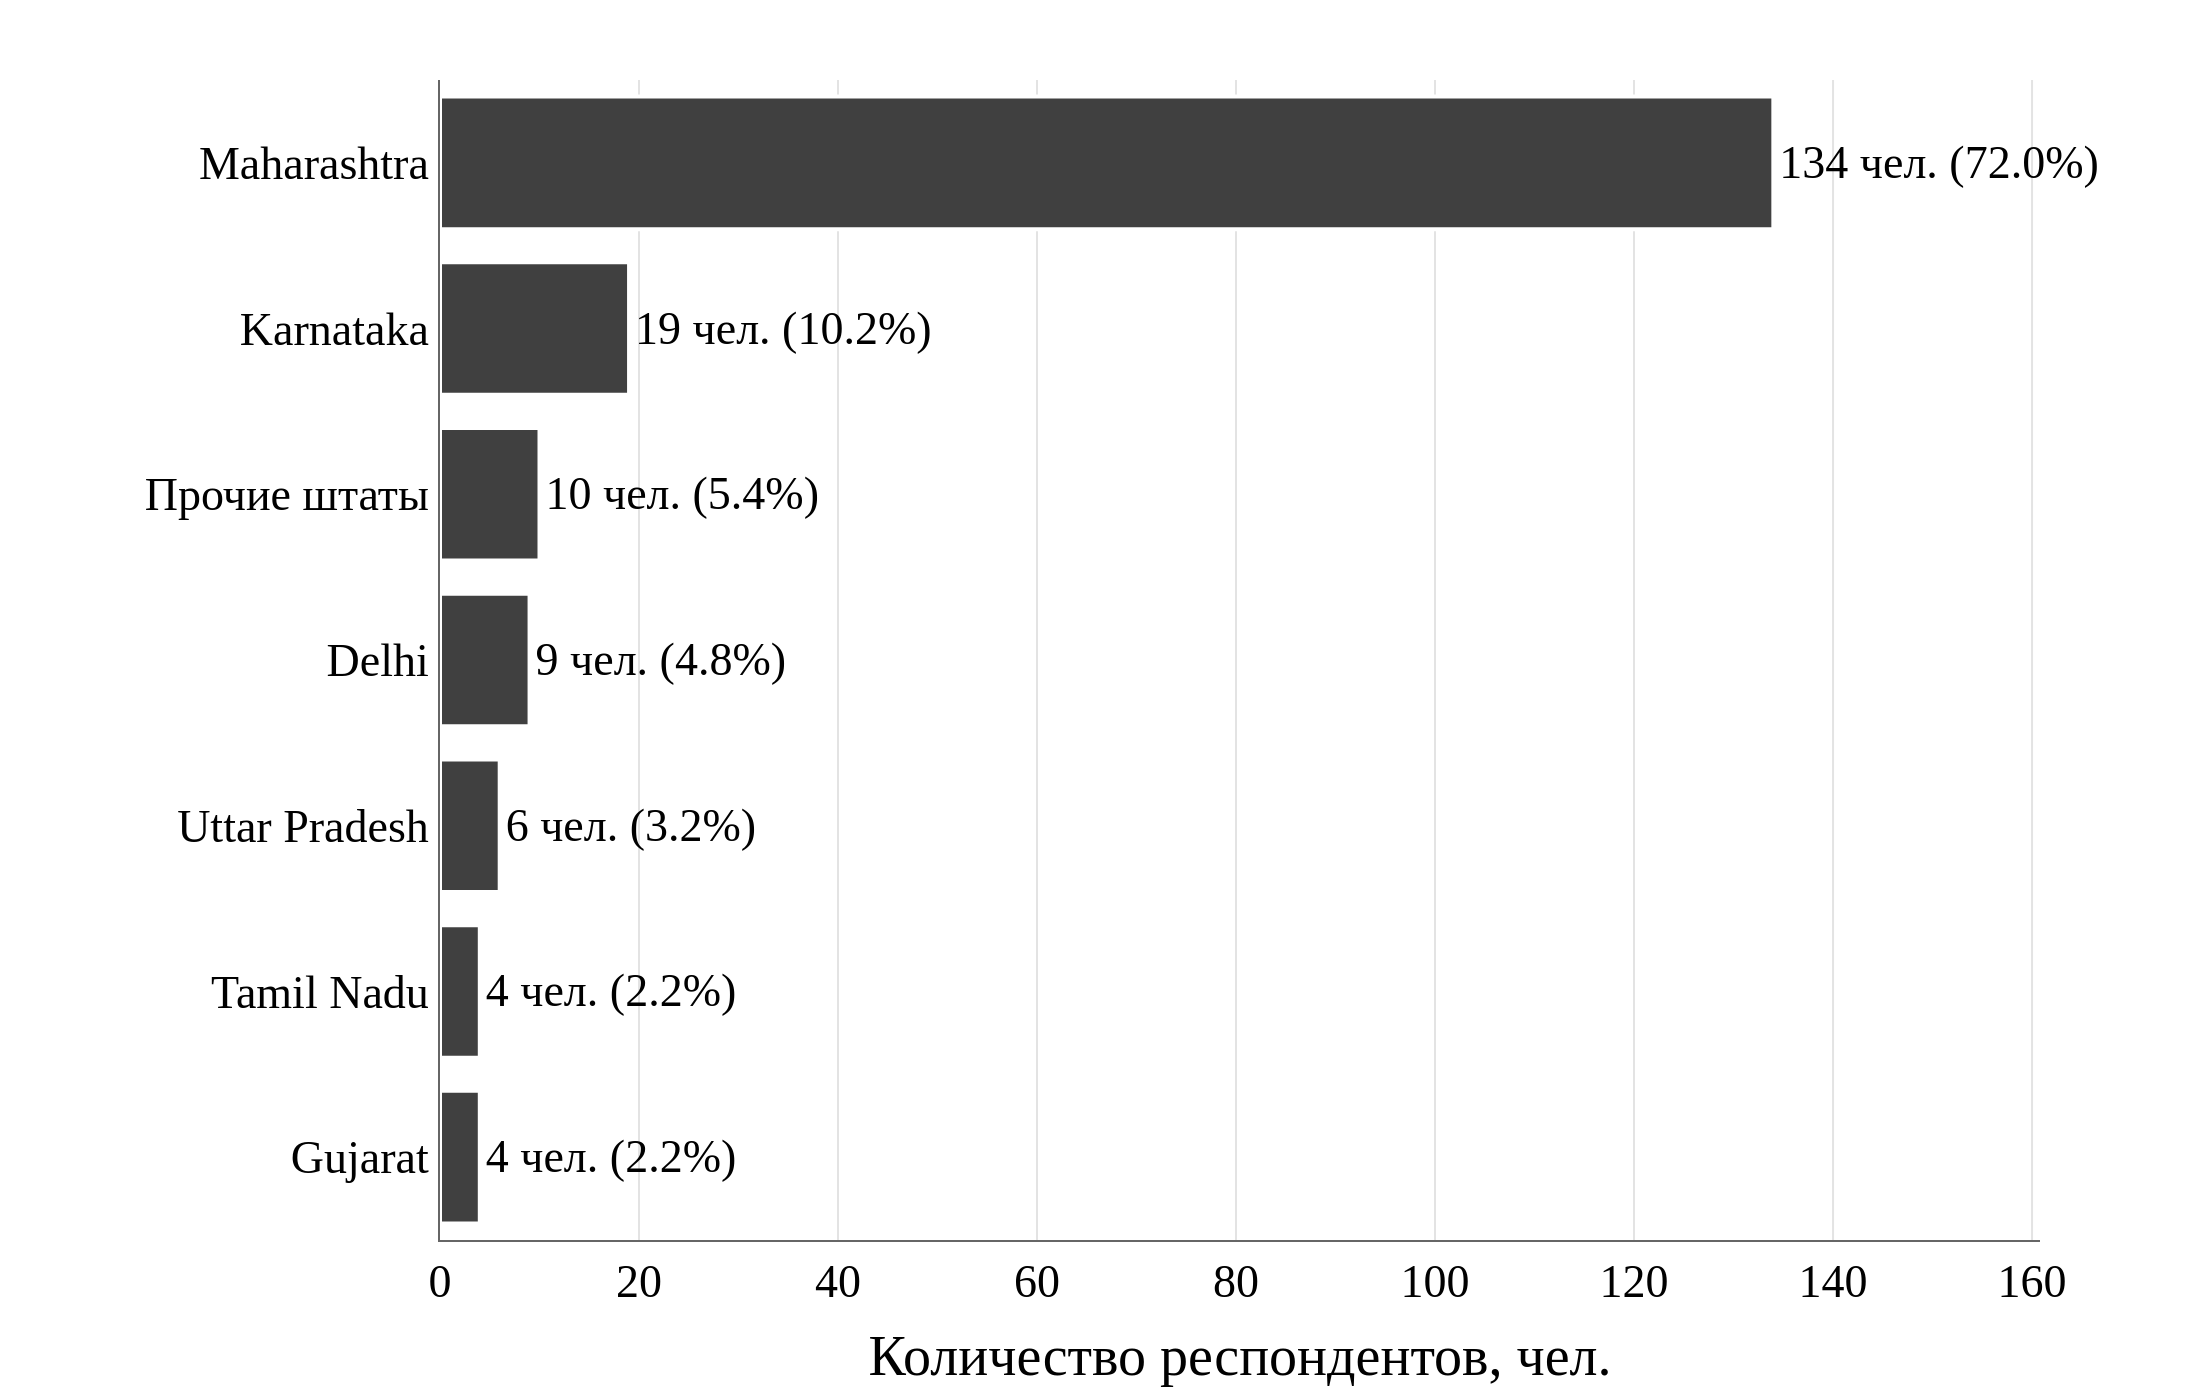

In [6]:
state_counts = df['Which state or union territory do you live in?'].value_counts()

top_n = 6
plot_counts = pd.concat([
    state_counts.head(top_n),
    pd.Series({'Прочие штаты': state_counts.iloc[top_n:].sum()})
]).sort_values(ascending=True)

total = len(df)

fig = go.Figure(data=[go.Bar(
    y=plot_counts.index,
    x=plot_counts.values,
    orientation='h',
    text=[f'{n} чел. ({n/total*100:.1f}%)' for n in plot_counts.values],
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='%{y}<br>Количество: %{x} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    width=1100,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    margin=dict(l=220, r=80, t=40, b=60),
    xaxis=dict(
        title='Количество респондентов, чел.',
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, plot_counts.max() * 1.2]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=23),
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        automargin=True
    )
)

fig.show()